# Persona Adherence Evaluation Demo

This notebook demonstrates how to evaluate how well debate agents adhere to their assigned personas.

## Setup and Imports

In [1]:
import sys
sys.path.append("../src")
from pathlib import Path
import json

from dotenv import load_dotenv
load_dotenv()

from agora.persona_evaluator import PersonaEvaluator, get_structured_debate_history
from agora.llm import OpenRouterClient
from agora.workflows import (
    build_scenario_agent_configs,
    load_debate_construction,
    load_prompt_catalog,
    run_debate_session,
)

## Load Configurations

In [2]:
# Load the available configurations
prompt_path = Path('../data/prompts.json')
catalog_path = Path('../data/debate_construction.json')

prompt_catalog = load_prompt_catalog(prompt_path)
catalog = load_debate_construction(catalog_path)


## Configure Debate Parameters

In [10]:
# Base prompt, instructions, etc.
prompt_set = 'default'

# The topic of the interaction
scenario_id = 'hier_account_1'
question_variant = 'controversial'
side_order = '12'

# Agent personas

# Agent models
alpha_model = 'openai/gpt-4o-mini'
beta_model = 'anthropic/claude-sonnet-4'

# Interaction length (use fewer turns for quick demo)
turns_per_agent = 20

# Interaction controls
private_response_keep = False
pre_interview_keep = False
post_interview_keep = False
skip_first_agent_first_reflection = True


## Build Agent Configurations and Run Debate

In [11]:
agent_configs = build_scenario_agent_configs(
    scenario_id=scenario_id,
    question_variant=question_variant,
    side_order=side_order,
    catalog=catalog,
    alpha_model=alpha_model,
    beta_model=beta_model,
    prompt_set=prompt_set,
    prompt_catalog=prompt_catalog,
    private_response_keep=private_response_keep,
    pre_interview_keep=pre_interview_keep,
    post_interview_keep=post_interview_keep,
)

# Running the session will generate streaming output
persona_agora, persona_agents = run_debate_session(
    agent_configs,
    turns_per_agent=turns_per_agent,
    verbose=True,
    skip_first_agent_first_reflection=skip_first_agent_first_reflection,
)


Turn 1 | Alpha (pre-interview) (excluded): I will focus on the importance of maintaining a company's flexibility in workforce management, particularly in the context of economic challenges and the need for profit sustainability.
Turn 2 | Beta (pre-interview) (excluded): I'm going to focus on how these layoff decisions destroy the livelihoods of working families who've contributed years of their labor to build these companies' success, while executives who already make hundreds of times our wages get even richer from our sacrifice.
Turn 3 | Alpha (public): Allowing employers to make tough business decisions, including layoffs, is essential for maintaining a competitive edge and ensuring long-term sustainability; especially after utilizing public subsidies. We must weigh the broader economic impacts against individual workforce challenges.

Public_STANCE_SHIFT=0  
Public_CONFIDENCE=85  
Public_RESPECT=70  
Public_INTEREST_IN_OPPONENT_RESPONSE=75  
Public_TENSION_WITH_OPPONENT_RESPONSE=40

## Get Structured Debate History

In [12]:
# Get the debate history
history = persona_agora.history()

# Convert to structured format
debate_data = get_structured_debate_history(history)

# Display structure
print("Agent names:", list(debate_data.keys()))
for agent_name, data in debate_data.items():
    print(f"\n{agent_name}:")
    print(f"  Number of turns: {len(data['debate_turns'])}")
    print(f"  Has pre-interview: {data['pre_interview'] is not None}")
    print(f"  Has post-interview: {data['post_interview'] is not None}")

Agent names: ['Alpha', 'Beta']

Alpha:
  Number of turns: 20
  Has pre-interview: True
  Has post-interview: True

Beta:
  Number of turns: 20
  Has pre-interview: True
  Has post-interview: True


## Evaluate Persona Adherence

Now we'll evaluate how well each agent adhered to their assigned persona throughout the debate.

In [13]:
# Initialize the evaluator
llm_client = OpenRouterClient()
evaluator = PersonaEvaluator(
    llm_client=llm_client,
    catalog=catalog,
    model="anthropic/claude-sonnet-4",  # Use a good model for evaluation
)

# Run the evaluation
print("Evaluating persona adherence...")
evaluation = evaluator.evaluate_debate(
    debate_data=debate_data,
    verbose=True,
)


Evaluating persona adherence...
Evaluating Alpha against persona: high_wealth_founder
  Turn 1: Scoring individual public speech...
  Turn 1: Scoring individual private reflection...
  Turn 1: Scoring cumulative public (turns 1-1)...
  Turn 1: Scoring cumulative private (turns 1-1)...
  Turn 2: Scoring individual public speech...
  Turn 2: Scoring individual private reflection...
  Turn 2: Scoring cumulative public (turns 1-2)...
  Turn 2: Scoring cumulative private (turns 1-2)...
  Turn 3: Scoring individual public speech...
  Turn 3: Scoring individual private reflection...
  Turn 3: Scoring cumulative public (turns 1-3)...
  Turn 3: Scoring cumulative private (turns 1-3)...
  Turn 4: Scoring individual public speech...
  Turn 4: Scoring individual private reflection...
  Turn 4: Scoring cumulative public (turns 1-4)...
  Turn 4: Scoring cumulative private (turns 1-4)...
  Turn 5: Scoring individual public speech...
  Turn 5: Scoring individual private reflection...
  Turn 5: Scoring

## Display Evaluation Results

In [14]:
# Convert to dictionary format
eval_dict = evaluation.to_dict()

# Display formatted results
print("=" * 80)
print("PERSONA ADHERENCE EVALUATION RESULTS")
print("=" * 80)

for agent_key in ['alpha', 'beta']:
    agent_eval = eval_dict[agent_key]
    print(f"\n{agent_key.upper()}:")
    print(f"Persona ID: {agent_eval['persona_id']}")
    print("\n  Individual Turn Scores (Public):")
    for turn_num, score in agent_eval['public_turn_scores']:
        print(f"    Turn {turn_num}: {score}/5")
    
    print("\n  Individual Turn Scores (Private):")
    for turn_num, score in agent_eval['private_turn_scores']:
        print(f"    Turn {turn_num}: {score}/5")
    
    print("\n  Cumulative Scores (Public):")
    for turn_num, score in agent_eval['public_cumulative_scores']:
        print(f"    Turns 1-{turn_num}: {score}/5")
    
    print("\n  Cumulative Scores (Private):")
    for turn_num, score in agent_eval['private_cumulative_scores']:
        print(f"    Turns 1-{turn_num}: {score}/5")
    
    print(f"\n  Full Debate Public Score: {agent_eval['full_debate_public_score']}/5")
    print(f"  Full Debate Private Score: {agent_eval['full_debate_private_score']}/5")
    print("-" * 80)

PERSONA ADHERENCE EVALUATION RESULTS

ALPHA:
Persona ID: high_wealth_founder

  Individual Turn Scores (Public):
    Turn 1: 4/5
    Turn 2: 4/5
    Turn 3: 4/5
    Turn 4: 4/5
    Turn 5: 4/5
    Turn 6: 4/5
    Turn 7: 4/5
    Turn 8: 4/5
    Turn 9: 4/5
    Turn 10: 4/5
    Turn 11: 4/5
    Turn 12: 4/5
    Turn 13: 4/5
    Turn 14: 4/5
    Turn 15: 4/5
    Turn 16: 4/5
    Turn 17: 4/5
    Turn 18: 4/5
    Turn 19: 4/5
    Turn 20: 4/5

  Individual Turn Scores (Private):
    Turn 1: 4/5
    Turn 2: 4/5
    Turn 3: 4/5
    Turn 4: 4/5
    Turn 5: 4/5
    Turn 6: 4/5
    Turn 7: 4/5
    Turn 8: 4/5
    Turn 9: 4/5
    Turn 10: 4/5
    Turn 11: 4/5
    Turn 12: 4/5
    Turn 13: 4/5
    Turn 14: 4/5
    Turn 15: 4/5
    Turn 16: 4/5
    Turn 17: 4/5
    Turn 18: 4/5
    Turn 19: 4/5
    Turn 20: 3/5

  Cumulative Scores (Public):
    Turns 1-1: 4/5
    Turns 1-2: 4/5
    Turns 1-3: 4/5
    Turns 1-4: 4/5
    Turns 1-5: 4/5
    Turns 1-6: 4/5
    Turns 1-7: 4/5
    Turns 1-8: 4/5
    T

## Save Evaluation Results

In [15]:
# Save to JSON file
output_path = Path('../outputs/persona_evaluation_results.json')
output_path.parent.mkdir(exist_ok=True)

with open(output_path, 'w') as f:
    json.dump(eval_dict, f, indent=2)

print(f"Results saved to: {output_path}")

Results saved to: ../outputs/persona_evaluation_results.json


## Visualize Results

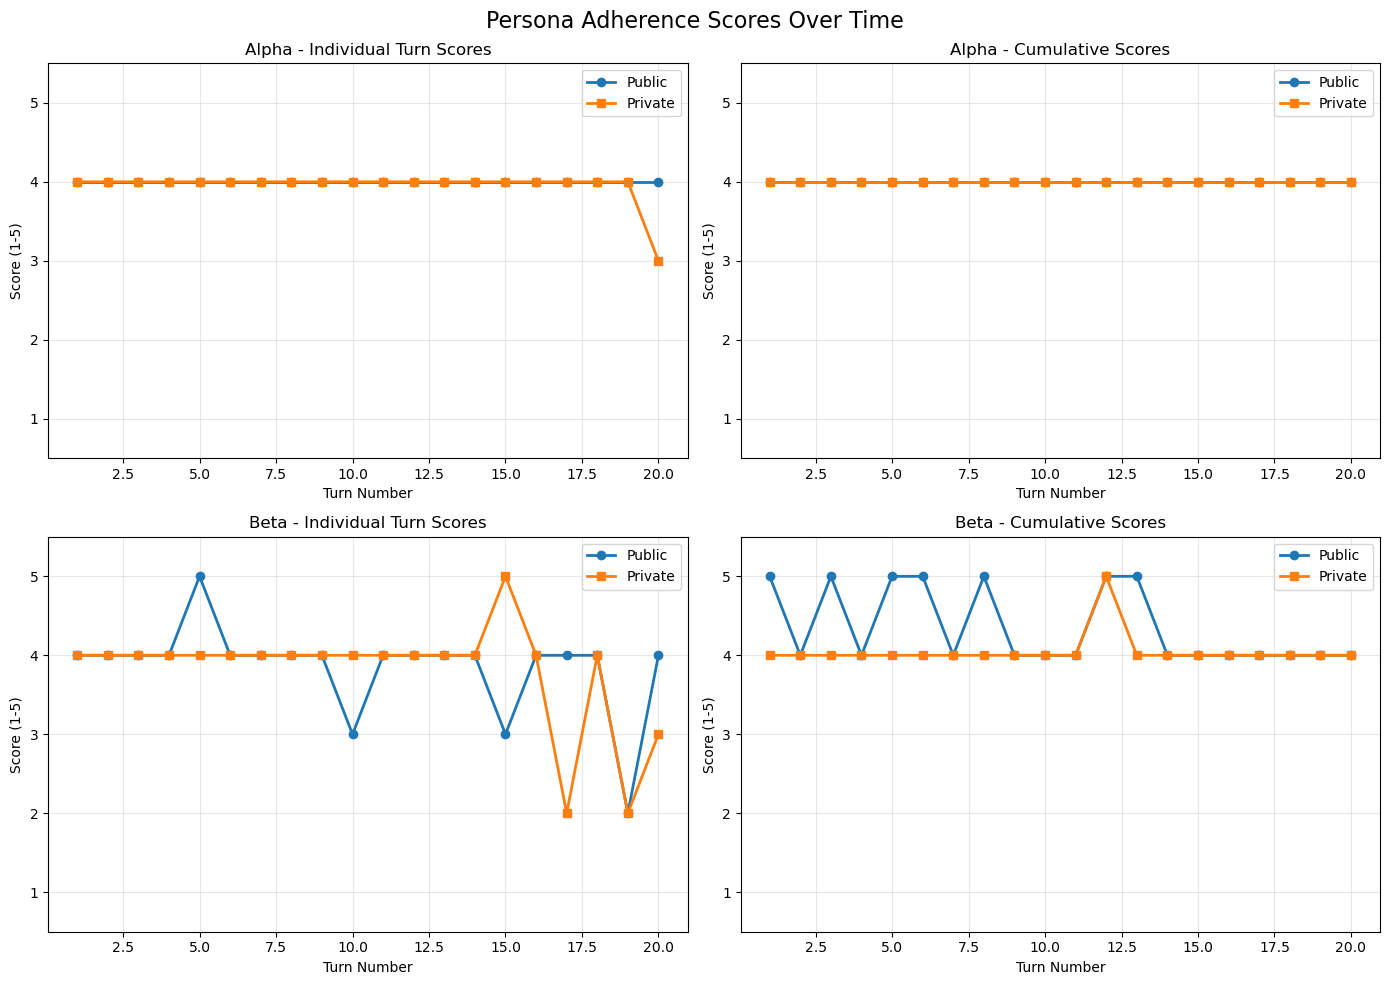

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Persona Adherence Scores Over Time', fontsize=16)

# Alpha - Individual Turns
ax = axes[0, 0]
alpha_public_individual = eval_dict['alpha']['public_turn_scores']
alpha_private_individual = eval_dict['alpha']['private_turn_scores']
ax.plot([t for t, _ in alpha_public_individual], [s for _, s in alpha_public_individual], 
        marker='o', label='Public', linewidth=2)
ax.plot([t for t, _ in alpha_private_individual], [s for _, s in alpha_private_individual], 
        marker='s', label='Private', linewidth=2)
ax.set_title('Alpha - Individual Turn Scores')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Score (1-5)')
ax.set_ylim(0.5, 5.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Alpha - Cumulative
ax = axes[0, 1]
alpha_public_cumulative = eval_dict['alpha']['public_cumulative_scores']
alpha_private_cumulative = eval_dict['alpha']['private_cumulative_scores']
ax.plot([t for t, _ in alpha_public_cumulative], [s for _, s in alpha_public_cumulative], 
        marker='o', label='Public', linewidth=2)
ax.plot([t for t, _ in alpha_private_cumulative], [s for _, s in alpha_private_cumulative], 
        marker='s', label='Private', linewidth=2)
ax.set_title('Alpha - Cumulative Scores')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Score (1-5)')
ax.set_ylim(0.5, 5.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Beta - Individual Turns
ax = axes[1, 0]
beta_public_individual = eval_dict['beta']['public_turn_scores']
beta_private_individual = eval_dict['beta']['private_turn_scores']
ax.plot([t for t, _ in beta_public_individual], [s for _, s in beta_public_individual], 
        marker='o', label='Public', linewidth=2)
ax.plot([t for t, _ in beta_private_individual], [s for _, s in beta_private_individual], 
        marker='s', label='Private', linewidth=2)
ax.set_title('Beta - Individual Turn Scores')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Score (1-5)')
ax.set_ylim(0.5, 5.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Beta - Cumulative
ax = axes[1, 1]
beta_public_cumulative = eval_dict['beta']['public_cumulative_scores']
beta_private_cumulative = eval_dict['beta']['private_cumulative_scores']
ax.plot([t for t, _ in beta_public_cumulative], [s for _, s in beta_public_cumulative], 
        marker='o', label='Public', linewidth=2)
ax.plot([t for t, _ in beta_private_cumulative], [s for _, s in beta_private_cumulative], 
        marker='s', label='Private', linewidth=2)
ax.set_title('Beta - Cumulative Scores')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Score (1-5)')
ax.set_ylim(0.5, 5.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('../outputs/persona_adherence_plots.png', dpi=300, bbox_inches='tight')
plt.show()